In [39]:
import nifty.re as jft
from jax import random
from jax import numpy as jnp
import jax
import matplotlib.pyplot as plt

jax.config.update("jax_enable_x64", True)

shape = 256
distances = 1
seed = 50
key = random.PRNGKey(seed)

In [40]:
def fieldmaker(shape, distances, prefix, **args):
    cfm = jft.CorrelatedFieldMaker(prefix=f"{prefix}")
    cfm.set_amplitude_total_offset(
    offset_mean=args["offset_mean"], offset_std=args["offset_std"]
    )
    args.pop("offset_mean")
    args.pop("offset_std")
    cfm.add_fluctuations(
    shape=shape,
    distances=distances,
    **args,
    )
    cf_model = cfm.finalize()
    return cf_model, cfm.power_spectrum

In [41]:
cf_kwargs = {
    "offset_mean": 21.0,
    "offset_std": (1.0, 1e-3),
    "fluctuations": (2.0, 1.0),
    "loglogavgslope": (-2.0, 0.3),
    "flexibility": (2.0, 1.0),
    "asperity": (1.0, 0.5),
    "prefix": "",
    }

In [42]:
model, ps = fieldmaker(shape=shape, distances=distances, **cf_kwargs)


In [43]:
key, *subkeys = random.split(key, 5)
xi_samples = [jft.random_like(sk, model.domain) for sk in subkeys]

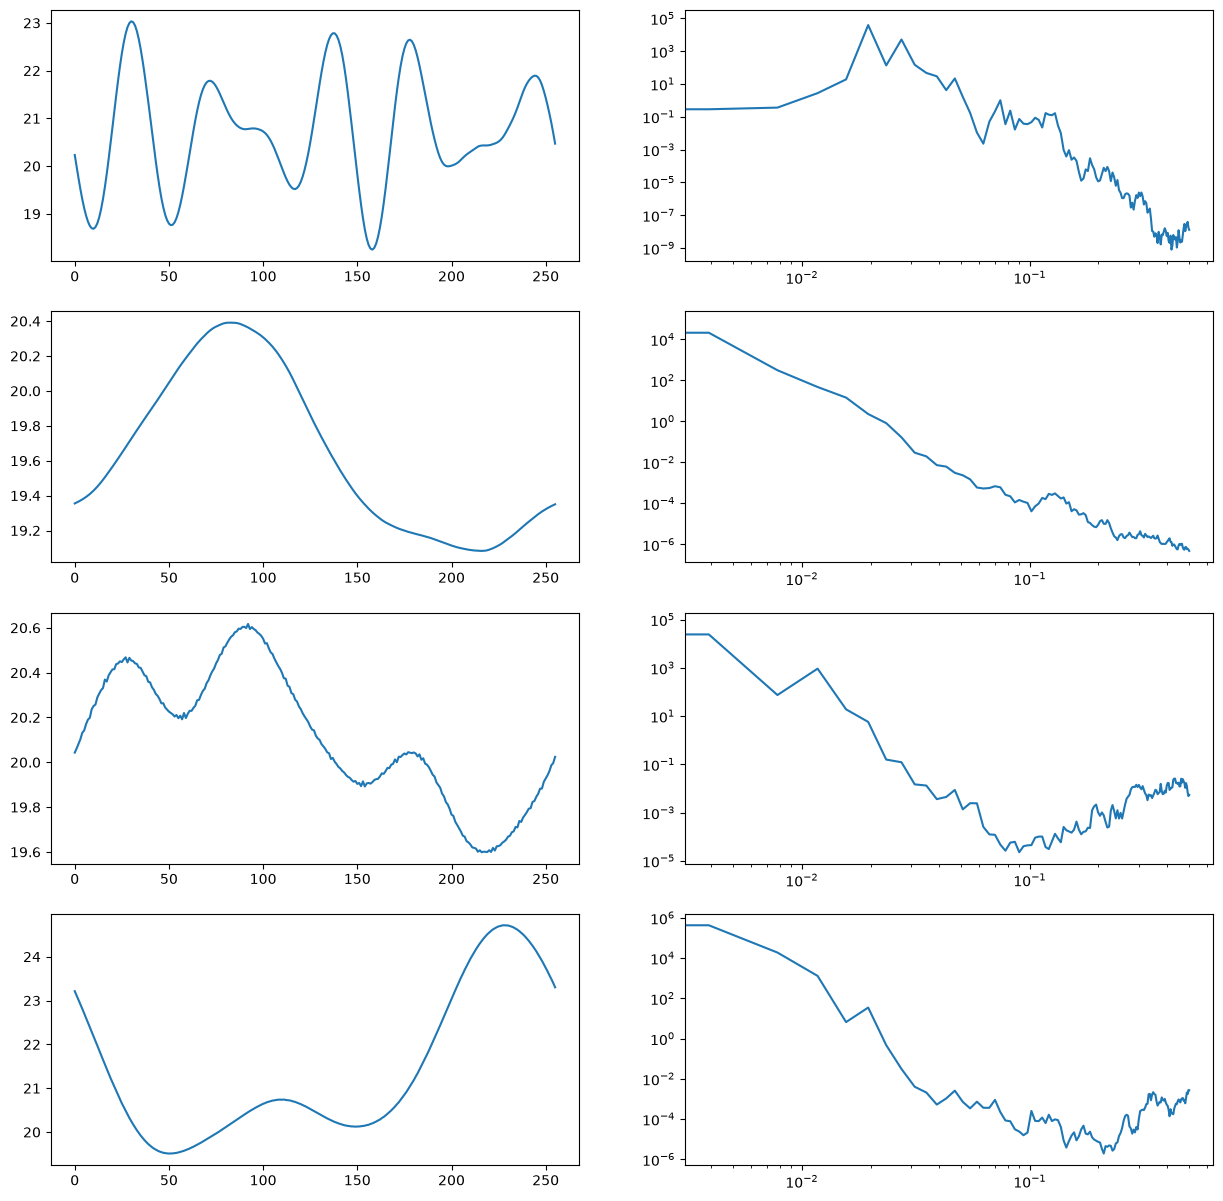

In [44]:
x_vec = model.target_grids[0].distances[0] * np.arange(
shape
) # sampling points of Gaussian process
k_vec = model.target_grids[
0
].harmonic_grid.mode_lengths # fourier modes of amplitude spectrum
fig, axes = plt.subplots(len(xi_samples), 2, figsize=(15, 15))
for i, xi in enumerate(xi_samples):
    axes[i, 0].plot(x_vec, model(xi))
    axes[i, 1].loglog(k_vec, ps(xi))
plt.show()

In [45]:
cf_kwargs = {
    "offset_mean": 0.0,
    "offset_std": (0.5, 0.2),
    "fluctuations": (1.0, 0.2),
    "loglogavgslope": (-2.0, 0.3),
    "flexibility": None,
    "asperity": None,
    "prefix": "",
    }

In [46]:
realisations = 5
def vary_parameter(parameter, values, **args):
    global key
    for i, j in  enumerate(values):
        syn_data = np.zeros(shape=(shape, realisations))
        syn_pow = np.zeros(shape=(int(shape / 2 + 1), realisations))
        args[parameter] = j
        fig = plt.figure(tight_layout=True, figsize=(10, 3))
        fig.suptitle(f"{parameter} = {j}")
        ax1 = fig.add_subplot(1, 2, 1)
        ax1.set_title("Field Realizations")
        ax1.set_ylim(-4.0,
        4,
        )
        ax2 = fig.add_subplot(1, 2, 2)
        ax2.set_xscale("log")
        ax2.set_yscale("log")
        ax2.set_title("Power Spectra")
        # Plotting different realisations for each field.
        for k in range(realisations):
            cf_model, pow_cf = fieldmaker(shape, distances, **args)
            key, signalk = jax.random.split(key, num=2)
            syn_signal = jft.random_like(signalk, cf_model.domain)
            syn_data[:, k] = cf_model(syn_signal)
            syn_pow[:, k] = pow_cf(syn_signal)
            ax1.plot(x_vec, syn_data[:, k], linewidth=1)
            ax2.plot(
                k_vec,
                np.sqrt(syn_pow[:, k]),
                linewidth=1,
        )

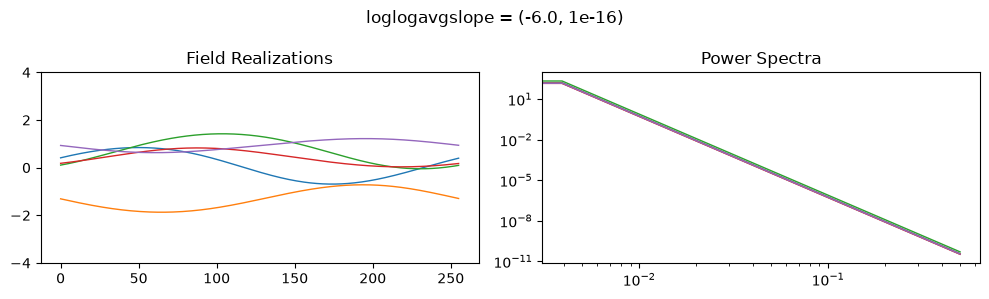

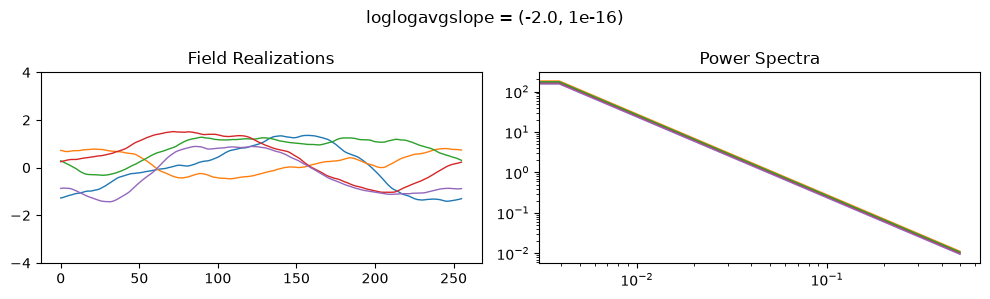

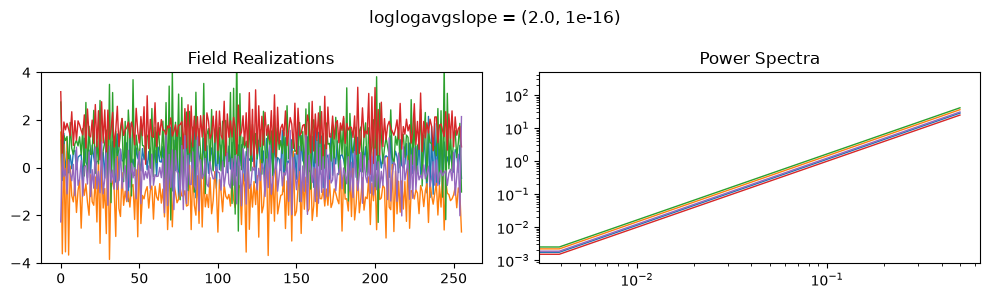

In [47]:
vary_parameter(
    "loglogavgslope",
    [(-6.0, 1e-16), (-2.0, 1e-16), (2.0, 1e-16)],
    **cf_kwargs,
)

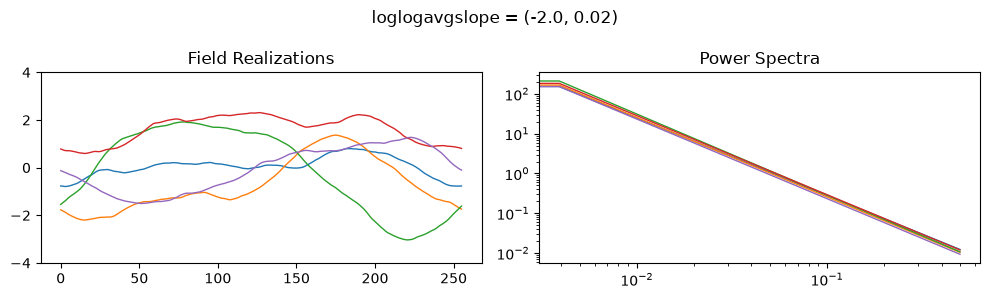

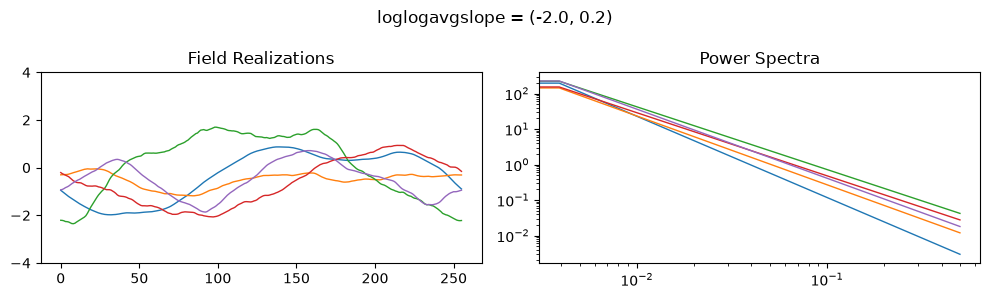

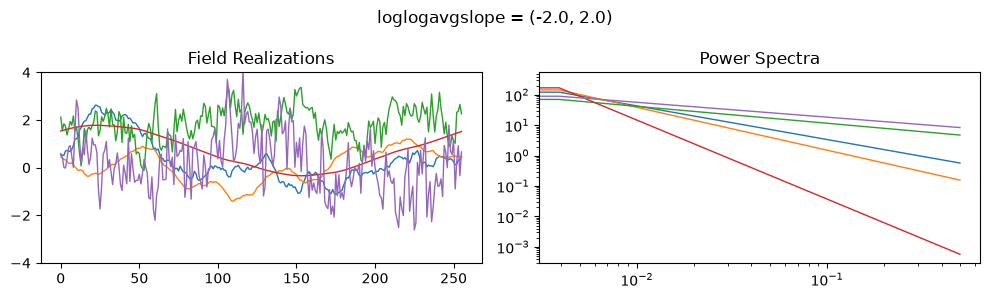

In [48]:
vary_parameter("loglogavgslope", [(-2.0, 0.02), (-2.0, 0.2), (-2.0, 2.0)], **cf_kwargs)
cf_kwargs["loglogavgslope"] = (-2.0, 1e-16)

In [49]:
cf_kwargs["fluctuations"] = (1.0, 1e-16)
cf_kwargs["flexibility"] = (1e-3, 1e-16)
cf_kwargs["asperity"] = (1e-3, 1e-16)

In [50]:
cf_kwargs["loglogavgslope"] = (-3, 1e-16)
cf_kwargs["offset_std"] = (1e-3, 1e-16)

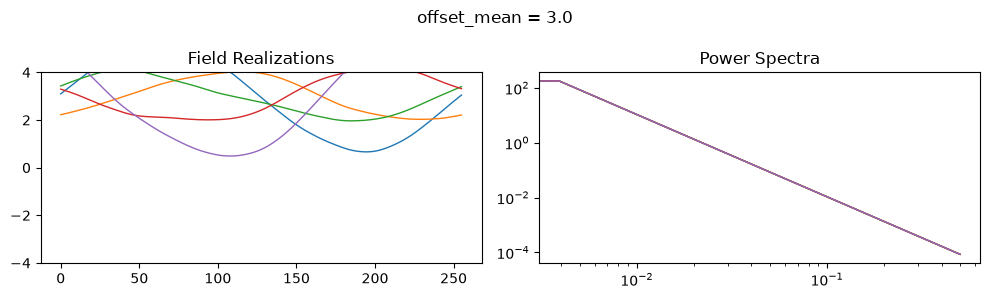

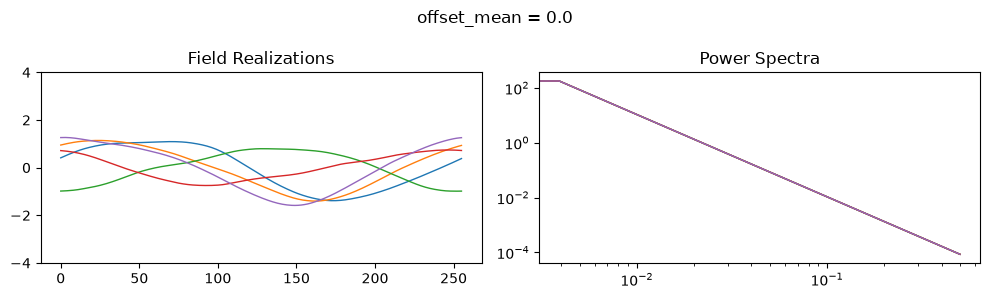

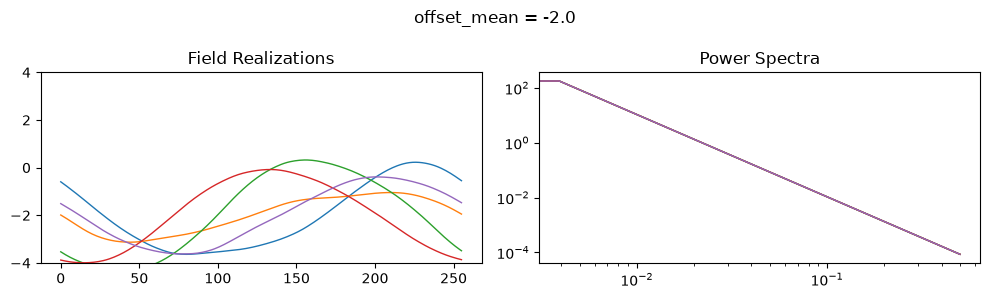

In [51]:
vary_parameter("offset_mean", [3.0, 0.0,-2.0], **cf_kwargs)
cf_kwargs["offset_mean"] = 0.0

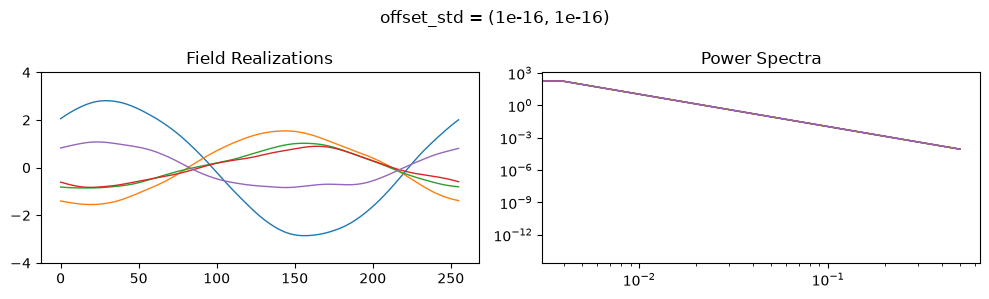

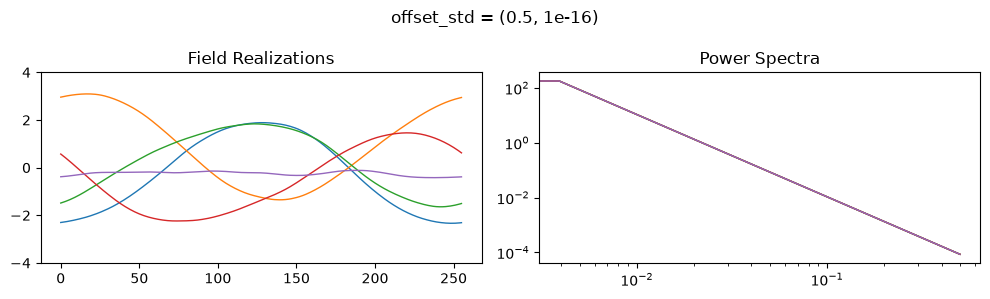

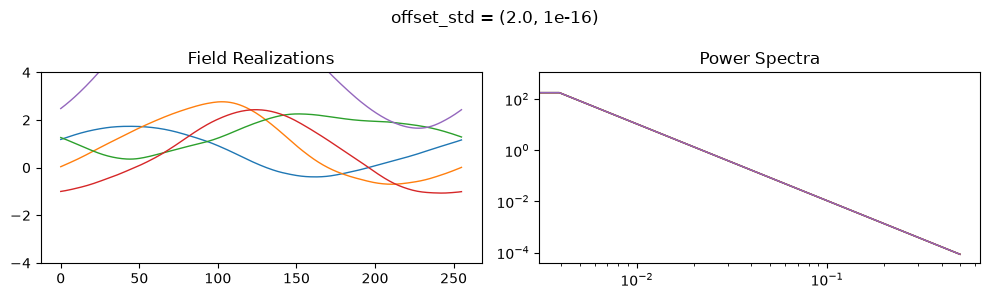

In [52]:
vary_parameter("offset_std", [(1e-16, 1e-16), (0.5, 1e-16), (2.0, 1e-16)], **cf_kwargs)

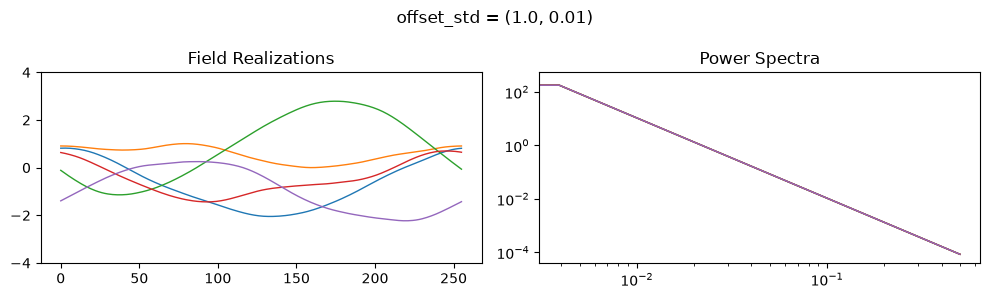

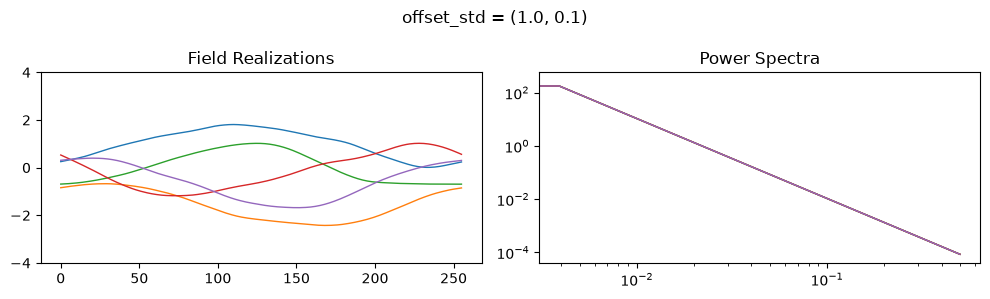

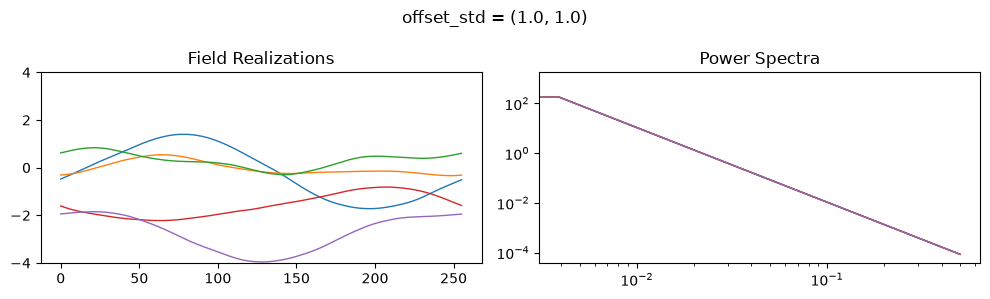

In [53]:
vary_parameter("offset_std", [(1.0, 0.01), (1.0, 0.1), (1.0, 1.0)], **cf_kwargs)
cf_kwargs["offset_std"] = (0.5, 0.2)

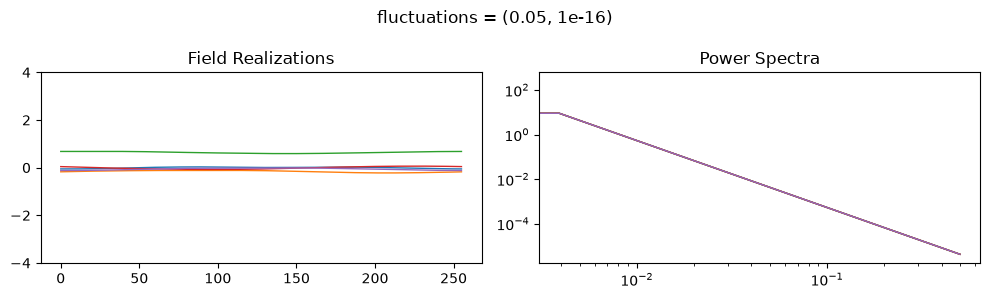

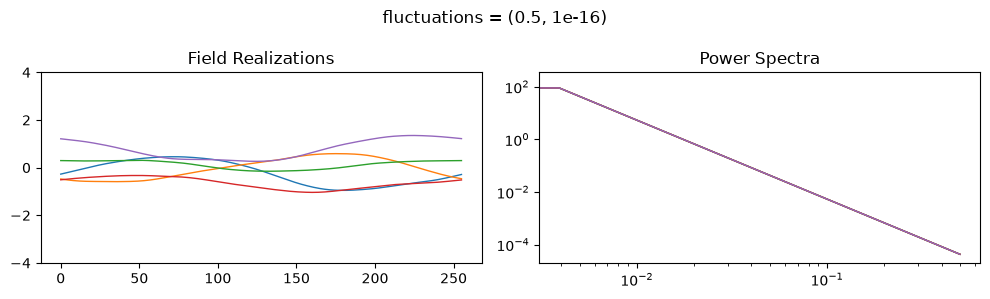

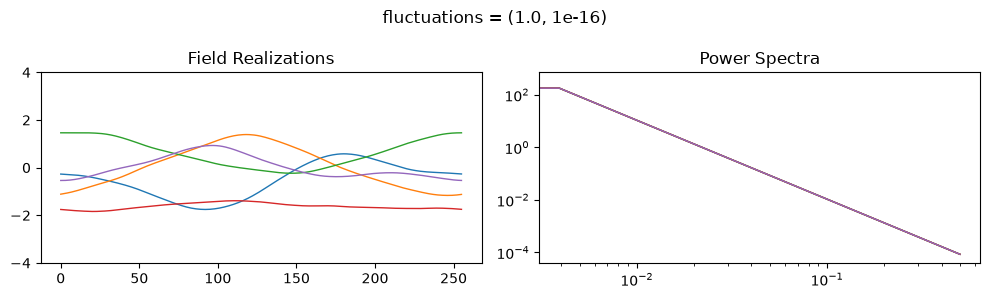

In [54]:
vary_parameter("fluctuations", [(0.05, 1e-16), (0.5, 1e-16), (1.0, 1e-16)], **cf_kwargs)
cf_kwargs["fluctuations"] = (1.0, 1e-16)

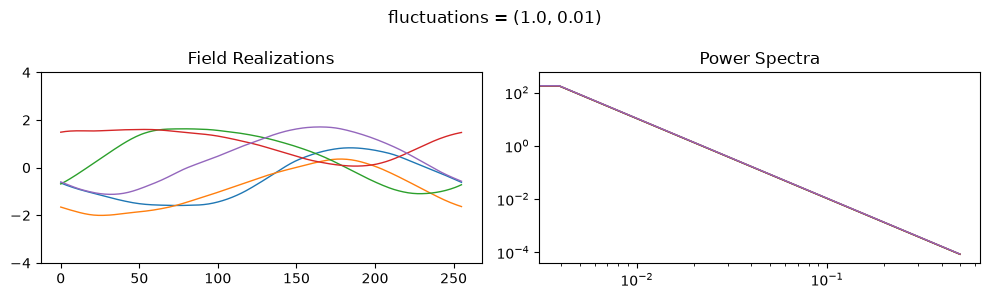

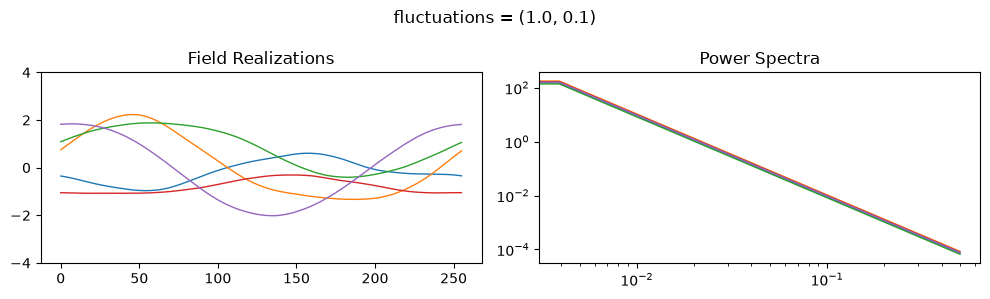

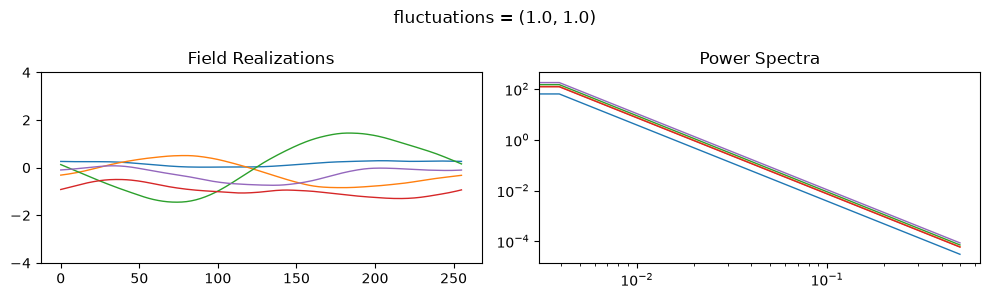

In [55]:
vary_parameter("fluctuations", [(1.0, 0.01), (1.0, 0.1), (1.0, 1.0)], **cf_kwargs)
cf_kwargs["fluctuations"] = (1.0, 1e-16)

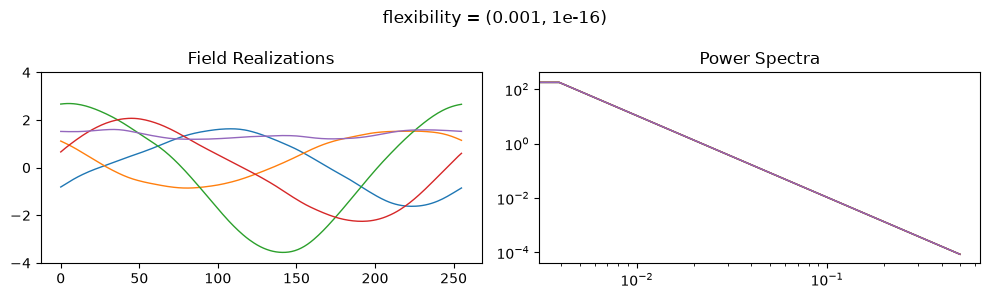

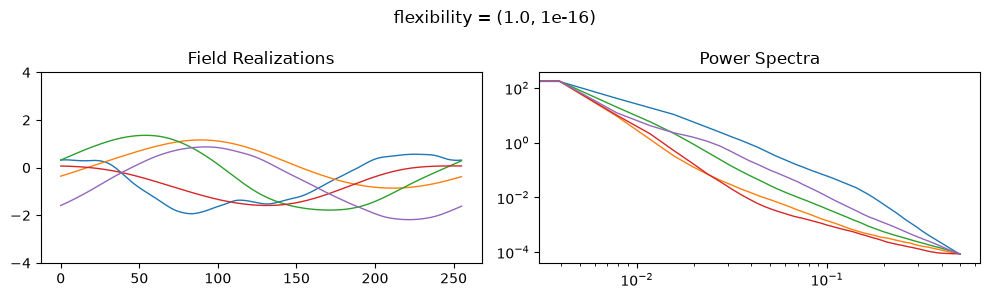

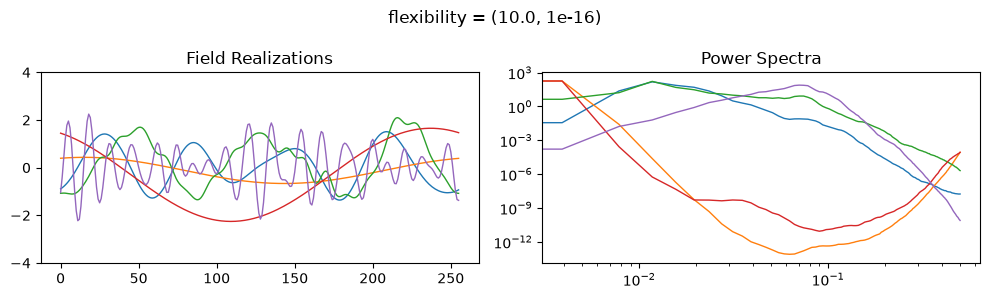

In [56]:
vary_parameter(
"flexibility", [(0.001, 1e-16), (1.0, 1e-16), (10.0, 1e-16)], **cf_kwargs
)

In [57]:
cf_kwargs["flexibility"] = (5.0, 1e-16)


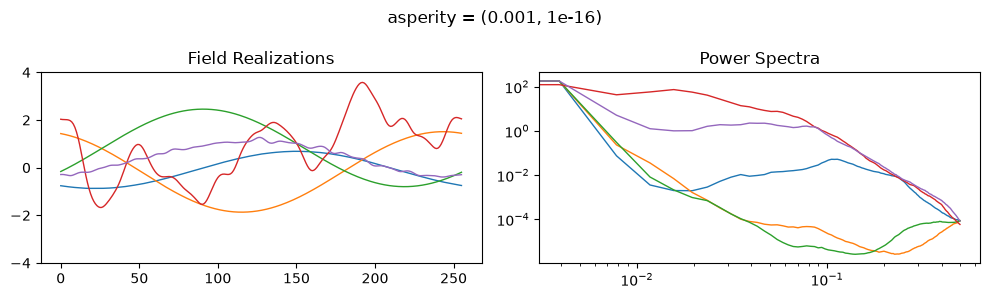

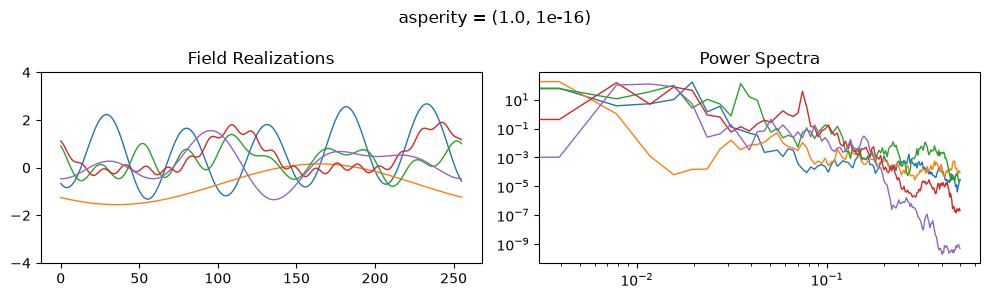

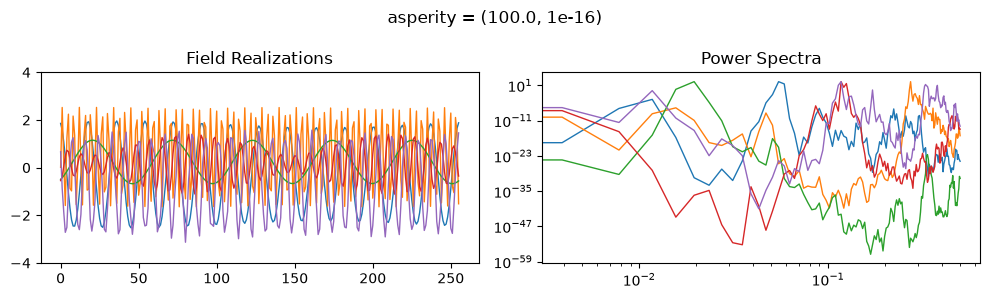

In [58]:
vary_parameter("asperity", [(0.001, 1e-16), (1.0, 1e-16), (100.0, 1e-16)], **cf_kwargs)